# DBSCAN — Density-Based Spatial Clustering of Applications with Noise

## What Is DBSCAN?

DBSCAN defines a cluster as a **dense region of points connected through their neighborhoods**. Rather than asking "which centroid is closest?" (K-Means), it asks: "are there enough points near here to call this a dense region?"

Two parameters control this:
- **ε (epsilon)**: the neighborhood radius
- **min_samples**: minimum points required within ε to be a *core point*

Every point is classified as:
- **Core point** — has ≥ `min_samples` neighbors within ε: anchors a cluster
- **Border point** — within ε of a core point but not dense enough itself: belongs to the cluster but does not expand it
- **Noise (−1)** — not reachable from any core point: outlier

Two core points are in the same cluster if they are within ε of each other. This **density-reachability** lets DBSCAN trace arbitrarily shaped clusters.

## 1. Setup & Data Generation

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os, sys

sys.path.insert(0, os.path.abspath('../../../src'))
from mlpackage.unsupervised_learning.dbscan import DBSCAN
from sklearn.datasets import make_moons, make_blobs
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import NearestNeighbors

CSV_PATH = 'moons_noise.csv'

if not os.path.exists(CSV_PATH):
    rng = np.random.default_rng(42)

    # Two crescent-shaped clusters
    X_moons, y_moons = make_moons(n_samples=300, noise=0.07, random_state=42)

    # Inject 30 uniformly distributed noise points
    noise_x = rng.uniform(-1.5, 2.5, (30, 2))
    is_noise = np.zeros(len(X_moons), dtype=int)
    is_noise_injected = np.ones(30, dtype=int)

    X_all = np.vstack([X_moons, noise_x])
    is_noise_all = np.concatenate([is_noise, is_noise_injected])

    df_out = pd.DataFrame(X_all, columns=['x', 'y'])
    df_out['is_noise'] = is_noise_all
    df_out.to_csv(CSV_PATH, index=False)
    print(f'Dataset generated: {len(X_moons)} moon points + 30 noise points.')
else:
    print('Dataset already present.')

df = pd.read_csv(CSV_PATH)
X_raw  = df[['x', 'y']].values
is_noise_gt = df['is_noise'].values   # ground truth noise labels
print(f'Shape: {df.shape}  |  Noise points: {is_noise_gt.sum()}')

Dataset already present.
Shape: (330, 3)  |  Noise points: 30


## 2. Explore the Raw Data

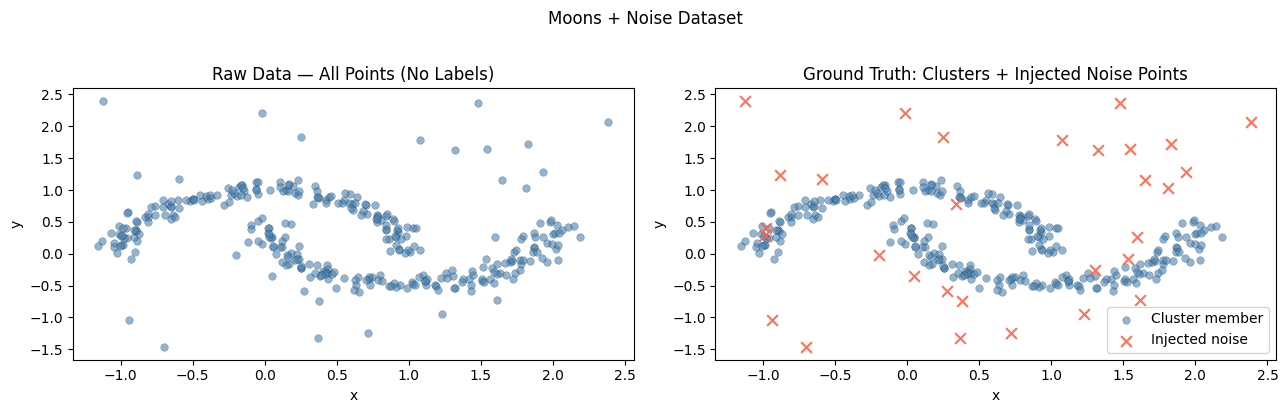

In [2]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# All points, no labels
axes[0].scatter(X_raw[:, 0], X_raw[:, 1],
                color='steelblue', alpha=0.6, s=30, edgecolors='k', lw=0.2)
axes[0].set_title('Raw Data — All Points (No Labels)')
axes[0].set_xlabel('x'); axes[0].set_ylabel('y')

# Ground truth: cluster vs noise
mask_cluster = is_noise_gt == 0
mask_noise   = is_noise_gt == 1
axes[1].scatter(X_raw[mask_cluster, 0], X_raw[mask_cluster, 1],
                color='steelblue', alpha=0.6, s=30,
                edgecolors='k', lw=0.2, label='Cluster member')
axes[1].scatter(X_raw[mask_noise, 0], X_raw[mask_noise, 1],
                color='tomato', alpha=0.9, s=60, marker='x',
                linewidths=1.5, label='Injected noise')
axes[1].set_title('Ground Truth: Clusters + Injected Noise Points')
axes[1].set_xlabel('x'); axes[1].set_ylabel('y')
axes[1].legend()

plt.suptitle('Moons + Noise Dataset', fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

The left plot shows raw data: two crescent shapes plus scattered points.  
Even without labels, the two dense arcs are obvious to a human. The scattered points in the space between and around the crescents do not clearly belong to either crescent.

The plot on the right shows the ground truth: blue points form the two crescents; red X marks are the injected noise points scattered uniformly across the space.

We want to see if DBSCAN can:
1. correctly separate the two crescents without being told K=2
2. identify the scattered noise points as outliers (label=-1) rather than forcing them into a cluster as K-Means would

## 3. Preprocessing

In [3]:
scaler = StandardScaler()
X = scaler.fit_transform(X_raw)

print(f'After scaling — Mean: {X.mean(axis=0).round(4)}, Std: {X.std(axis=0).round(4)}')

After scaling — Mean: [ 0. -0.], Std: [1. 1.]


ε is a distance threshold in feature space.  
If features are on different scales, ε means different things in each direction.  
StandardScaler ensures ε has a consistent geometric meaning across all dimensions.

## 4. Choosing ε — The k-Distance Plot

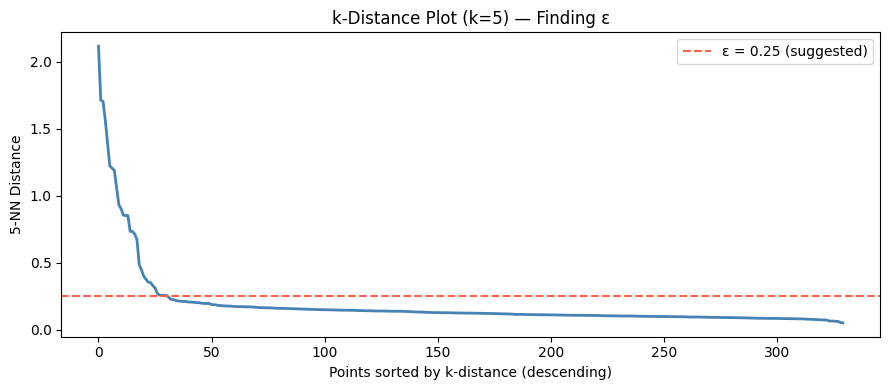

In [4]:
min_samples = 5   # rule of thumb: 2 * n_features = 2*2 = 4, round up to 5

nbrs = NearestNeighbors(n_neighbors=min_samples).fit(X)
distances, _ = nbrs.kneighbors(X)
k_distances = np.sort(distances[:, -1])[::-1]   # distance to k-th neighbor, sorted descending

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(k_distances, color='steelblue', linewidth=2)
ax.axhline(0.25, color='tomato', linestyle='--', linewidth=1.5, label='ε = 0.25 (suggested)')
ax.set_xlabel('Points sorted by k-distance (descending)')
ax.set_ylabel(f'{min_samples}-NN Distance')
ax.set_title(f'k-Distance Plot (k={min_samples}) — Finding ε')
ax.legend()
plt.tight_layout()
plt.show()

In the plot above we have:
- X-axis: all data points, sorted by their distance to their k-th nearest neighbor (from largest to smallest, most isolated first).
- Y-axis: said distance.

Far left (high k-distance): isolated points with no close neighbors. These are the noise/outlier candidates.
Far right (low k-distance): tightly packed points inside dense clusters.

The elbow (sharp bend) separates noise from cluster members:
- Set ε at the elbow: points to the left of the elbow (above the ε line) will be labeled noise (their k-th neighbor is farther than ε).
- Points to the right (below ε) are core or border points.

Too small ε: too many points labeled noise, clusters fragment.
Too large ε: noise absorbed into clusters, clusters merge.
The elbow gives the natural separation between dense and sparse regions.

## 5. Running DBSCAN

In [5]:
eps_chosen = 0.25

db = DBSCAN(eps=eps_chosen, min_samples=min_samples)
labels = db.fit_predict(X)

n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
n_noise    = (labels == -1).sum()

print(f'ε = {eps_chosen}, min_samples = {min_samples}')
print(f'Clusters found : {n_clusters}')
print(f'Noise points   : {n_noise}  (out of {len(labels)} total)')
print(f'Label distribution: {dict(zip(*np.unique(labels, return_counts=True)))}')

ε = 0.25, min_samples = 5
Clusters found : 2
Noise points   : 24  (out of 330 total)
Label distribution: {np.int64(-1): np.int64(24), np.int64(0): np.int64(153), np.int64(1): np.int64(153)}


## 6. Visualizing DBSCAN Results

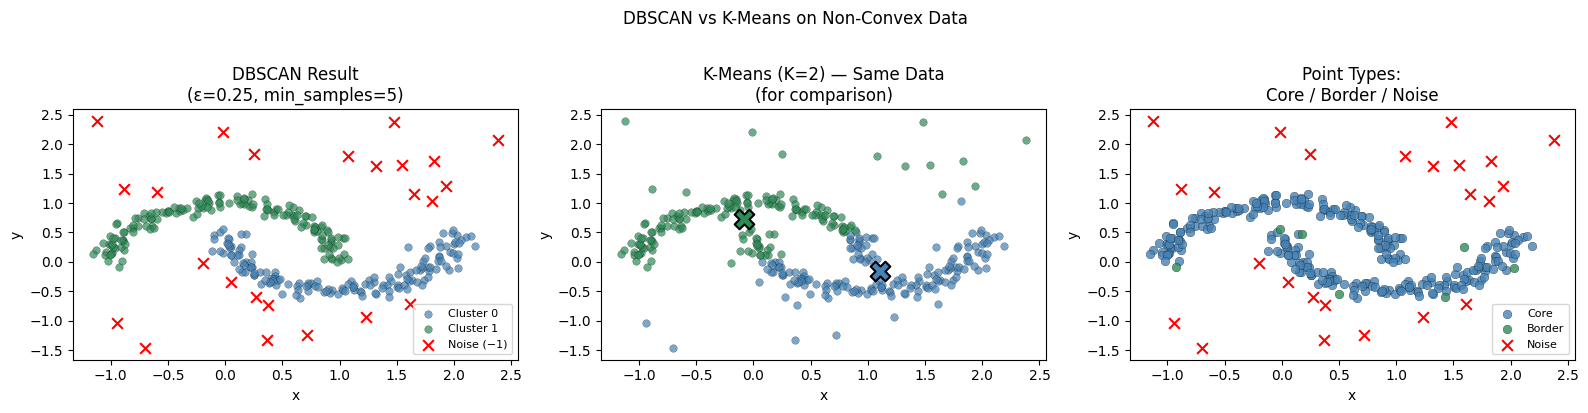

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

cluster_colors = ['steelblue', 'seagreen', 'orange', 'purple']

# Panel 1: DBSCAN result
noise_mask = labels == -1
for k in sorted(set(labels) - {-1}):
    mask = labels == k
    axes[0].scatter(X_raw[mask, 0], X_raw[mask, 1],
                    color=cluster_colors[k], alpha=0.7, s=30,
                    edgecolors='k', lw=0.2, label=f'Cluster {k}')
axes[0].scatter(X_raw[noise_mask, 0], X_raw[noise_mask, 1],
                color='red', s=60, marker='x', lw=1.5, label='Noise (−1)')
axes[0].set_title(f'DBSCAN Result\n(ε={eps_chosen}, min_samples={min_samples})')
axes[0].set_xlabel('x'); axes[0].set_ylabel('y')
axes[0].legend(fontsize=8)

# Panel 2: K-Means on the same data (for comparison)
from mlpackage.unsupervised_learning.kmeans import kmeans as MyKMeans
km = MyKMeans(k=2, random_state=42)
km.fit(X)
km_labels = km.predict(X)
for k in range(2):
    mask = km_labels == k
    axes[1].scatter(X_raw[mask, 0], X_raw[mask, 1],
                    color=cluster_colors[k], alpha=0.7, s=30,
                    edgecolors='k', lw=0.2)
    c = scaler.inverse_transform(km.centroids_[k:k+1])[0]
    axes[1].scatter(c[0], c[1], color=cluster_colors[k],
                    s=200, marker='X', edgecolors='black', lw=1.5, zorder=5)
axes[1].set_title('K-Means (K=2) — Same Data\n(for comparison)')
axes[1].set_xlabel('x'); axes[1].set_ylabel('y')

# Panel 3: Point types (core / border / noise)
if hasattr(db, 'core_sample_indices_'):
    core_mask   = np.zeros(len(X), dtype=bool)
    core_mask[db.core_sample_indices_] = True
    border_mask = (~core_mask) & (labels != -1)

    axes[2].scatter(X_raw[core_mask, 0],   X_raw[core_mask, 1],
                    color='steelblue', alpha=0.8, s=40, label='Core', edgecolors='k', lw=0.2)
    axes[2].scatter(X_raw[border_mask, 0], X_raw[border_mask, 1],
                    color='seagreen',  alpha=0.8, s=40, label='Border', edgecolors='k', lw=0.2)
    axes[2].scatter(X_raw[noise_mask, 0],  X_raw[noise_mask, 1],
                    color='red', s=60, marker='x', lw=1.5, label='Noise')
    axes[2].set_title('Point Types:\nCore / Border / Noise')
    axes[2].legend(fontsize=8)
else:
    axes[2].scatter(X_raw[~noise_mask, 0], X_raw[~noise_mask, 1],
                    color='steelblue', alpha=0.7, s=30, label='Cluster member')
    axes[2].scatter(X_raw[noise_mask, 0],  X_raw[noise_mask, 1],
                    color='red', s=60, marker='x', lw=1.5, label='Noise (−1)')
    axes[2].set_title('Cluster Members vs Noise')
    axes[2].legend(fontsize=8)
axes[2].set_xlabel('x'); axes[2].set_ylabel('y')

plt.suptitle('DBSCAN vs K-Means on Non-Convex Data', fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

The plot on the left shows the DBSCAN result:  
Blue and green correctly trace the two crescent shapes.  
Red X marks are labeled noise (−1), they have no dense neighborhood.  
DBSCAN discovered K=2 without being told, and flagged outliers.

The center plot shows the K-Means result on the same data:  
K-Means bisects the space with a straight-line boundary. Each crescent is split across both clusters, which is a complete failure on this geometry.  
K-Means also cannot label any point as noise: every point belongs to the nearest centroid regardless of how isolated it is.

The right plot shows point types:
Core points (blue): densely packed, each has ≥ min_samples neighbors within ε. These form the skeleton of the clusters.
Border points (green): close to core points but not dense enough themselves. They sit at the edge of the cluster.
Noise (red X): far from any core point, outliers.

The core/border/noise classification is DBSCAN's internal logic made visible.

## 7. Effect of ε and min_samples

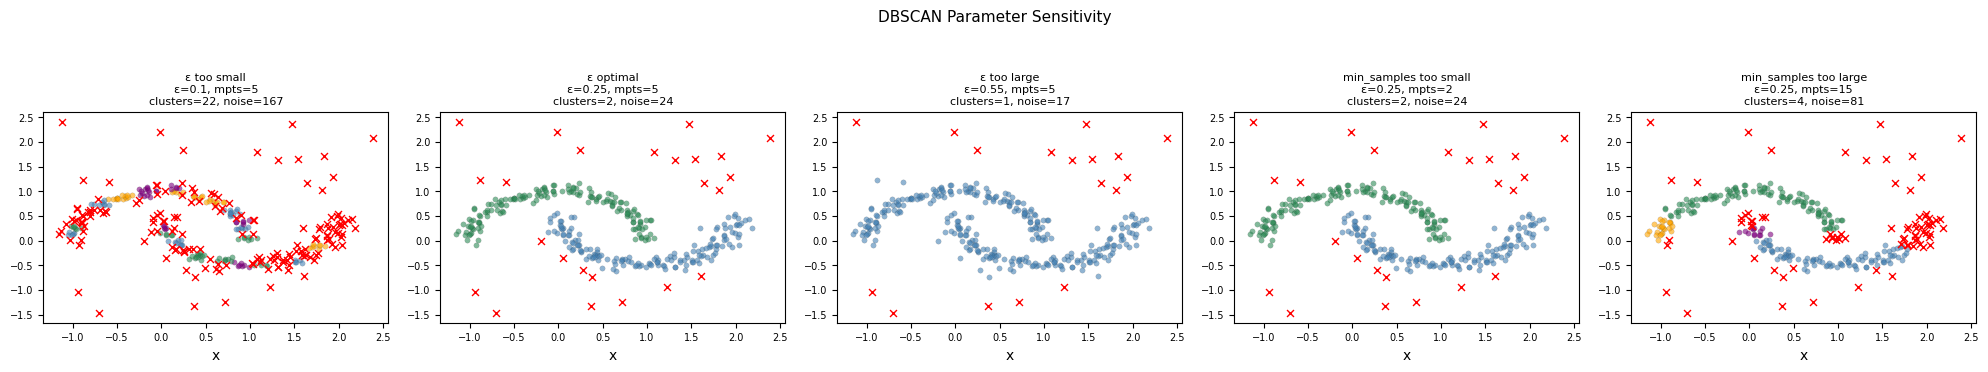

In [8]:
param_grid = [
    (0.10, 5, 'ε too small'),
    (0.25, 5, 'ε optimal'),
    (0.55, 5, 'ε too large'),
    (0.25, 2, 'min_samples too small'),
    (0.25, 15,'min_samples too large'),
]

fig, axes = plt.subplots(1, 5, figsize=(20, 3.5))

for ax, (eps, mpts, title) in zip(axes, param_grid):
    db_tmp = DBSCAN(eps=eps, min_samples=mpts)
    labs_tmp = db_tmp.fit_predict(X)
    n_cl  = len(set(labs_tmp)) - (1 if -1 in labs_tmp else 0)
    n_no  = (labs_tmp == -1).sum()

    noise_m = labs_tmp == -1
    unique_labs = sorted(set(labs_tmp) - {-1})
    for k in unique_labs:
        ax.scatter(X_raw[labs_tmp==k, 0], X_raw[labs_tmp==k, 1],
                   color=cluster_colors[k % len(cluster_colors)],
                   alpha=0.6, s=15, edgecolors='k', lw=0.1)
    ax.scatter(X_raw[noise_m, 0], X_raw[noise_m, 1],
               color='red', s=25, marker='x', lw=1)
    ax.set_title(f'{title}\nε={eps}, mpts={mpts}\n'
                 f'clusters={n_cl}, noise={n_no}', fontsize=8)
    ax.set_xlabel('x'); ax.tick_params(labelsize=7)

plt.suptitle('DBSCAN Parameter Sensitivity', fontsize=11, y=1.05)
plt.tight_layout()
plt.show()

Each panel above changes one parameter while holding the other fixed.

ε too small (leftmost): the neighborhood is too tight. Most points have fewer than min_samples neighbors and get labeled noise. The clusters fragment into many tiny pieces or disappear entirely.

ε optimal (second): clean separation of the two crescents, noise correctly identified. This is the elbow of the k-distance plot.

ε too large (third): the neighborhood expands so far that the two crescents merge into one cluster, and noise points get absorbed. The algorithm loses its ability to distinguish between the two shapes.

min_samples too small (fourth): even isolated noise points now qualify as core points (they need fewer neighbors). Many spurious small clusters form in what should be noise regions.

  min_samples too large (fifth): the density requirement is too strict.
    Even the genuine cluster points do not have enough neighbors to be core
    points, so large parts of the crescents are labeled noise.

ε and min_samples jointly define what 'dense' means.  
  The k-distance plot provides a data-driven way to set ε;  
  min_samples = 2×n_features is a reasonable starting point.

## 8. Outlier Detection — DBSCAN vs Ground Truth

Outlier Detection Performance:
  True Positives  (correctly flagged noise):   24
  False Positives (cluster member → noise):    0
  False Negatives (noise → cluster member):    6
  True Negatives  (correctly kept in cluster): 300
  Precision: 1.000  |  Recall: 0.800


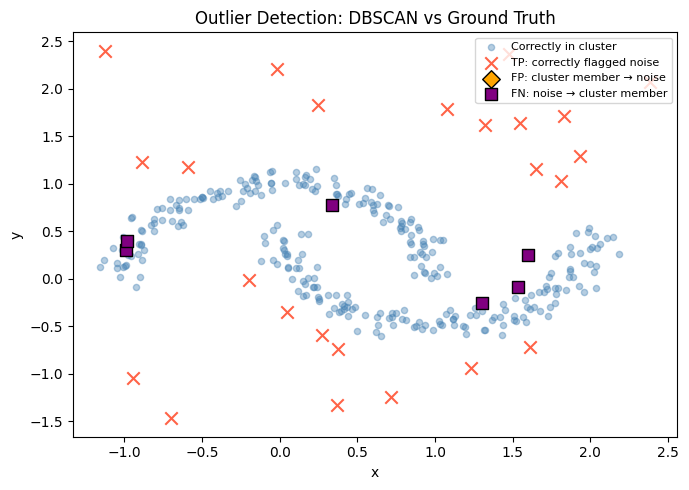

In [9]:
# Treat noise label (-1) as the positive class for outlier detection
db_noise = (labels == -1).astype(int)
gt_noise  = is_noise_gt

tp = ((db_noise == 1) & (gt_noise == 1)).sum()
fp = ((db_noise == 1) & (gt_noise == 0)).sum()
fn = ((db_noise == 0) & (gt_noise == 1)).sum()
tn = ((db_noise == 0) & (gt_noise == 0)).sum()

precision = tp / (tp + fp) if (tp + fp) > 0 else 0
recall    = tp / (tp + fn) if (tp + fn) > 0 else 0

print('Outlier Detection Performance:')
print(f'  True Positives  (correctly flagged noise):   {tp}')
print(f'  False Positives (cluster member → noise):    {fp}')
print(f'  False Negatives (noise → cluster member):    {fn}')
print(f'  True Negatives  (correctly kept in cluster): {tn}')
print(f'  Precision: {precision:.3f}  |  Recall: {recall:.3f}')

# Visualize misses and false alarms
fig, ax = plt.subplots(figsize=(7, 5))

tp_mask = (db_noise == 1) & (gt_noise == 1)
fp_mask = (db_noise == 1) & (gt_noise == 0)
fn_mask = (db_noise == 0) & (gt_noise == 1)
tn_mask = (db_noise == 0) & (gt_noise == 0)

ax.scatter(X_raw[tn_mask, 0], X_raw[tn_mask, 1],
           color='steelblue', alpha=0.4, s=20, label='Correctly in cluster')
ax.scatter(X_raw[tp_mask, 0], X_raw[tp_mask, 1],
           color='tomato', s=80, marker='x', lw=1.5, label='TP: correctly flagged noise')
ax.scatter(X_raw[fp_mask, 0], X_raw[fp_mask, 1],
           color='orange', s=80, marker='D', lw=1, edgecolors='k',
           label='FP: cluster member → noise')
ax.scatter(X_raw[fn_mask, 0], X_raw[fn_mask, 1],
           color='purple', s=80, marker='s', lw=1, edgecolors='k',
           label='FN: noise → cluster member')

ax.set_xlabel('x'); ax.set_ylabel('y')
ax.set_title('Outlier Detection: DBSCAN vs Ground Truth')
ax.legend(fontsize=8, loc='upper right')
plt.tight_layout()
plt.show()

The blue dots show cluster members which are correctly kept, i.e. the clean crescent points.  
Red X are noise points correctly identified (true positives).  
Orange diamonds are cluster members wrongly flagged as noise (false positives). These are typically border points near the edge of a crescent. Their
    local neighborhood is slightly less dense than the cluster interior.  
  Purple squares show noise points absorbed into a cluster (false negatives).
    These noise points happened to land near a dense region.

  The precision/recall scores quantify the trade-off:  
    - High precision = when DBSCAN says 'noise', it's usually right.  
    - High recall = it caught most of the true noise points.  
  ε controls this trade-off: smaller ε means more noise labels (higher recall,
  lower precision); larger ε means fewer noise labels (higher precision, lower recall).

## 9. DBSCAN on More Complex Structure

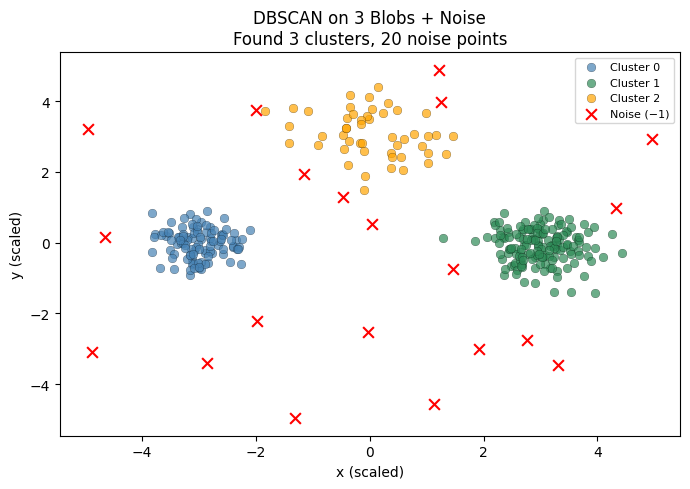

In [10]:
from sklearn.datasets import make_blobs

# Mix: 3 blobs of different sizes + noise
rng = np.random.default_rng(7)
X_b, _ = make_blobs(n_samples=[100, 50, 150],
                    centers=[[-3, 0], [0, 3], [3, 0]],
                    cluster_std=[0.4, 0.8, 0.5], random_state=7)
X_noise = rng.uniform(-5, 5, (20, 2))
X_complex = np.vstack([X_b, X_noise])
X_complex_s = StandardScaler().fit_transform(X_complex)

db_complex = DBSCAN(eps=0.3, min_samples=5)
labs_complex = db_complex.fit_predict(X_complex_s)

n_cl_c = len(set(labs_complex)) - (1 if -1 in labs_complex else 0)
n_no_c = (labs_complex == -1).sum()

fig, ax = plt.subplots(figsize=(7, 5))
all_colors = cluster_colors + ['brown', 'pink']
for k in sorted(set(labs_complex) - {-1}):
    mask = labs_complex == k
    ax.scatter(X_complex[mask, 0], X_complex[mask, 1],
               color=all_colors[k], alpha=0.7, s=40,
               edgecolors='k', lw=0.2, label=f'Cluster {k}')
noise_m = labs_complex == -1
ax.scatter(X_complex[noise_m, 0], X_complex[noise_m, 1],
           color='red', s=60, marker='x', lw=1.5, label='Noise (−1)')
ax.set_title(f'DBSCAN on 3 Blobs + Noise\n'
             f'Found {n_cl_c} clusters, {n_no_c} noise points')
ax.set_xlabel('x (scaled)'); ax.set_ylabel('y (scaled)')
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

DBSCAN handles varying cluster sizes naturally. It found all three blobs
  and flagged the sparse noise points, without requiring K in advance.

  DBSCAN's key limitation is visible here if the cluster densities differ
  significantly: a single ε cannot be simultaneously 'dense enough' for
  a tight cluster and 'not too small' for a sparser one. The medium-density
  blob may partially fragment or merge with noise depending on ε.  
  HDBSCAN (hierarchical DBSCAN) addresses this by varying ε automatically.

## 10. Key Takeaways

- The **k-distance plot** is DBSCAN's equivalent of the elbow plot: its elbow gives the right ε.
- The **three-panel comparison** (DBSCAN result, K-Means result, point types) makes the core superiority of DBSCAN on non-convex data visible: K-Means bisects the space; DBSCAN traces the density.
- The **parameter sensitivity grid** shows that both ε and min_samples matter and interact. Too small or too large in either dimension breaks the result in predictable ways.
- **Outlier detection is 'automatic'**: every point DBSCAN cannot assign to a cluster gets label −1. K-Means has no noise concept and forces every point into the nearest cluster, hiding outliers.
- DBSCAN's one limitation is **varying cluster densities**: a fixed ε cannot simultaneously capture tight and loose clusters. When this is a concern, HDBSCAN or hierarchical approaches should be considered.

## Why DBSCAN?

DBSCAN is uniquely demonstrated by this data because:

- **Non-convex clusters**: the two crescent shapes cannot be separated by any centroid-based method (including K-Means). DBSCAN connects points through density chains and naturally traces the crescent shapes.
- **Explicit noise points**: injected random noise points have no dense neighborhood. DBSCAN correctly labels them −1 while K-Means would force them into a cluster. This makes outlier detection directly observable.
- **No K to specify**: the number of clusters (2) emerges automatically from the density structure. There is no elbow plot or silhouette loop needed.
- **Controlled complexity**: 2 features means every concept (core points, border points, noise, neighborhood radius ε) can be shown directly on a scatter plot with no dimensionality reduction.